# Runge–Kutta methods

The aim is to solve the equation
$$
\frac{dy}{dt} = f(t,y).
$$

Let's start with the Taylor expansion:
$$
y(t_0 + h) \simeq y_0 + h y_0' + \frac{h^2}{2} y_0'' + \dots + \frac{h^k}{k!} y_0^{(k)} + \text{H.O.T.}
$$

where $y^{(i)}_0 = y^{(i)}(t_0)$. Let us express the derivatives in terms of $f$:
$$
\begin{aligned}
y'_0 &= f(t_0, y_0),\\
y''_0 &= f_t + f f_y,\\
y'''_0 &= f_{tt} + 2f f_{ty} + f^2 f_{yy} + (f_t + f f_y) f_y,
\end{aligned}
$$
all evaluated at $(t_0, y_0)$.

Now let us return to Runge–Kutta (RK) methods:
$$
y^{n+1} \simeq y^n + \sum_{i=1}^s b_i K_i(h),
$$

where the stages $K_i$ are defined as
$$
\begin{aligned}
K_1 &= h f(t^n, y^n),\\
K_2 &= h f(t^n + c_2 h, y^n + a_{21} K_1),\\
K_3 &= h f(t^n + c_3 h, y^n + a_{31} K_1 + a_{32} K_2),\\
&\ \vdots \\
K_s &= h f\left(t^n + c_s h, y^n + \sum_{l=1}^{s-1} a_{sl} K_l\right).
\end{aligned}
$$

Thus, the method is defined by the parameter set
$$
\{b_i,\; c_i,\; a_{ij}\}.
$$

A particular Runge–Kutta scheme is obtained by matching the Taylor expansion with the RK approximation up to the desired order.

---

### Second-order Runge–Kutta (explicit)

Consider a 2-stage explicit RK method:
$$
y^{n+1} = y^n + h\left(b_1 f(t^n, y^n) + b_2 f(t^n + c_2 h, y^n + h a_{21} f(t^n, y^n))\right).
$$

Stages:
$$
\begin{aligned}
K_1 &= f(t^n, y^n),\\
K_2 &= f(t^n + c_2 h, y^n + h a_{21} K_1),\\
y^{n+1} &= y^n + h(b_1 K_1 + b_2 K_2).
\end{aligned}
$$

Taylor expansion of the RK scheme:
$$
y^{n+1} = y^n + h(b_1 + b_2) f(t^n, y^n)
+ h^2 b_2 \left[c_2 f_t + a_{21} f_y f\right](t^n, y^n) + O(h^3).
$$

Compare with the true Taylor expansion:
$$
y^{n+1} = y^n + h f(t^n, y^n)
+ \frac{h^2}{2} \left[f_t + f_y f\right](t^n, y^n) + O(h^3).
$$

This yields the conditions:
$$
b_1 + b_2 = 1, \quad
b_2 c_2 = \frac{1}{2}, \quad
b_2 a_{21} = \frac{1}{2}.
$$

Thus, a one-parameter family of second-order RK methods can be written as
$$
b_1 = 1 - \alpha, \quad
b_2 = \alpha, \quad
a_{21} = c_2 = \frac{1}{2\alpha}.
$$

If we choose $\alpha = \tfrac{1}{2}$, we obtain the classical scheme:
$$
y^{n+1} = y^n + \frac{h}{2} \left[
f(t^n, y^n) + f(t^n + h, y^n + h f(t^n, y^n))
\right].
$$

---

### Butcher tableau

All Runge–Kutta methods can be compactly represented using the **Butcher tableau**:
$$
\begin{array}{c|cccc}
c_1 & 0      &        &        &   \\
c_2 & a_{21} & 0      &        &   \\
c_3 & a_{31} & a_{32} & 0      &   \\
\vdots & \vdots & \vdots & \ddots & \\
c_s & a_{s1} & a_{s2} & \cdots & 0 \\
\hline
    & b_1    & b_2    & \cdots & b_s
\end{array}
$$

Here:
- $A = (a_{ij})$ is the matrix of stage coefficients,
- $c = (c_i)$ are the nodes,
- $b = (b_i)$ are the weights.

For explicit methods, $A$ is strictly lower triangular ($a_{ij} = 0$ for $j \ge i$).

This tableau provides a unified way to describe RK methods and serves as the basis for deriving order conditions and stability properties.

---

### From Butcher tableau to stability function

To study stability, we consider the Dahlquist test equation:
$$
\frac{dy}{dt} = \lambda y.
$$

Applying a Runge–Kutta method to this equation, all stages become linear:
$$
K_i = h \lambda \left( y^n + \sum_{j=1}^{i-1} a_{ij} K_j \right).
$$

Let us introduce the vector of stages:
$$
K = (K_1, \dots, K_s)^T.
$$

Then the method can be written in matrix form:
$$
K = h \lambda \left( y^n \mathbf{1} + A K \right),
$$
where:
- $A = (a_{ij})$ is the Butcher matrix,
- $\mathbf{1} = (1, \dots, 1)^T$.

Rearranging:
$$
(I - z A) K = z y^n \mathbf{1}, \quad z = h \lambda.
$$

Solving for $K$:
$$
K = z (I - z A)^{-1} \mathbf{1} \, y^n.
$$

Substituting into the update formula:
$$
y^{n+1} = y^n + \sum_{i=1}^s b_i K_i,
$$

we obtain:
$$
y^{n+1} = R(z)\, y^n,
$$

where the **stability function** is
$$
R(z) = 1 + z\, b^T (I - z A)^{-1} \mathbf{1}.
$$

---

## Example: Explicit Euler

$$
R(z) = 1 + z
$$

👉 Stable only inside a small circle

---

## Let's Plot Stability Regions

We now visualize where:
$$
|R(z)| \le 1
$$

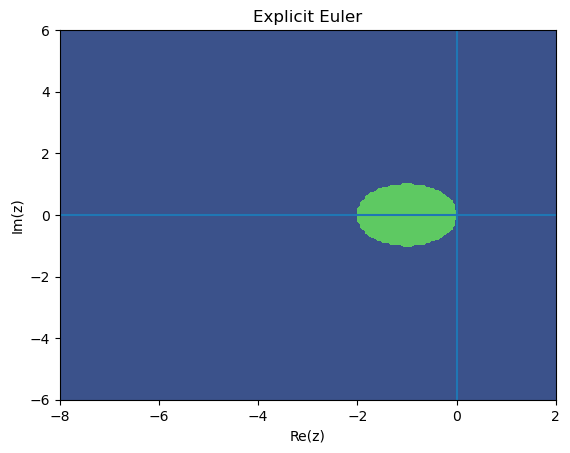

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.close('all')  # 

def plot_stability(R, title=""):
    x = np.linspace(-8, 2, 200)
    y = np.linspace(-6, 6, 200)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j*Y
    
    values = np.abs(R(Z))
    
    plt.figure()
    
    plt.contourf(X, Y, values <= 1)
    plt.axhline(0)
    plt.axvline(0)
    plt.title(title)
    plt.xlabel("Re(z)")
    plt.ylabel("Im(z)")
    plt.show()
plot_stability(lambda z: 1 + z, "Explicit Euler")

The pakage rk-stability-explorer offers a bunch of prescribed methods:

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import rk_stability_explorer as rk

rk.list_methods()

['BDF2',
 'ars22',
 'bogacki_shampine',
 'dop853',
 'dopri5',
 'euler',
 'explicit_midpoint',
 'gauss_legendre_2',
 'heun',
 'implicit_midpoint',
 'kvarno',
 'optRK4',
 'optRK62',
 'ps36',
 'radauIIA',
 'rk3',
 'rk4',
 'skewedrk4',
 'spijker',
 'ssprk33',
 'williamson']

New method can be either prescribed as a .yaml file in src/methods or defined as the folllwoing:

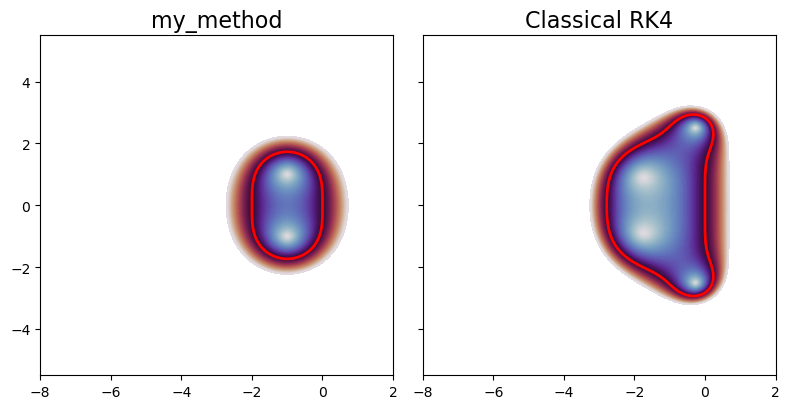

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import rk_stability_explorer as rk

plt.close('all')  # clean up figures

custom_method = {
    "A": [[0, 0],
          [1, 0]],
    "b": [0.5, 0.5],
    "name": "my_method"
}

methods = [
     custom_method,
     "rk4"
]

X, Y = rk.make_grid(n=200)
Z = X + 1j * Y

results = rk.compute_results(methods, X, Y, Z)
rk.rkplot_multiple(results, cols=2)
plt.show()

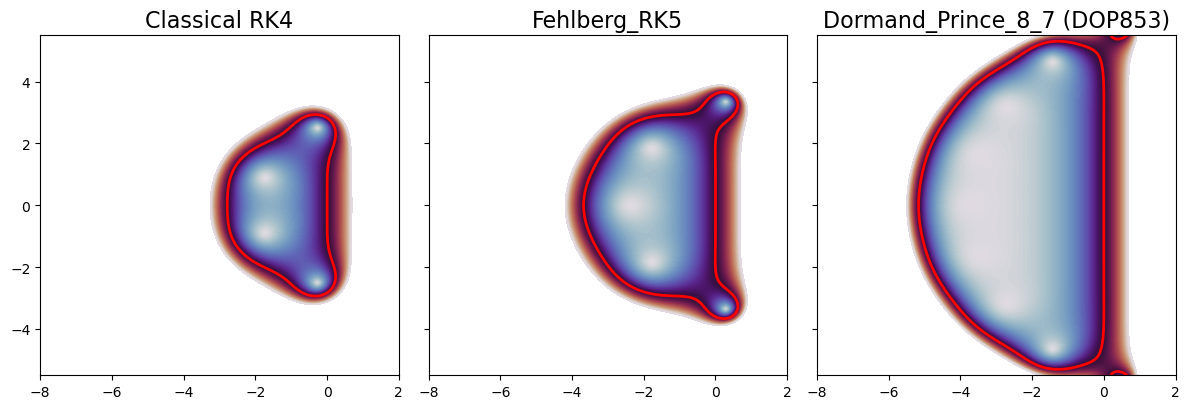

In [12]:
import matplotlib.pyplot as plt
plt.close('all')  # clean up figures
rkf5 = {
    "A": [
        [0, 0, 0, 0, 0, 0],
        [1/4, 0, 0, 0, 0, 0],
        [3/32, 9/32, 0, 0, 0, 0],
        [1932/2197, -7200/2197, 7296/2197, 0, 0, 0],
        [439/216, -8, 3680/513, -845/4104, 0, 0],
        [-8/27, 2, -3544/2565, 1859/4104, -11/40, 0]
    ],
    "b": [16/135, 0, 6656/12825, 28561/56430, -9/50, 2/55],
    "name": "Fehlberg_RK5"
}

methods = [
    "rk4",
    rkf5, "dop853"
]

X, Y = rk.make_grid(n=200)
Z = X + 1j * Y

results = rk.compute_results(methods, X, Y, Z)
rk.rkplot_multiple(results, cols=3)
plt.show()

In [ ]:
#fig.savefig("Rk4-8.png",  dpi=200, bbox_inches = 'tight', pad_inches = 0)